# Student Admission Probability - Regression Project
**Author**: Miguel Pajuelo Gómez 

**Degree**: Mathematical Engineering & Artificial Inteligence

A supervised and unsupervised machine learning analysis of the **Graduate Admissions Dataset**. The objective is to estimate the continuous variable `Chance of Admit` from the academic profile of each applicant and to compare several regression models under the same train/test split.

---

## Workflow

1. **Data loading & inspection** — understand the variables and the distribution of the target  
2. **Exploratory analysis** — study relationships between the academic features and admission probability  
3. **Preprocessing** — split the data and scale the predictors without data leakage  
4. **Unsupervised analysis** — use PCA and K-Means to identify latent applicant profiles  
5. **Supervised learning** — train and compare several regression models  
6. **Model comparison** — summarize performance using R², MAE and RMSE  
7. **Conclusions**

**Disclaimer:** This is an academic project where Spanish and English are both used in the explanations.


## 1. Imports

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from sklearn.model_selection import train_test_split, GridSearchCV, KFold
from sklearn.preprocessing import StandardScaler

from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

from sklearn.metrics import silhouette_score, r2_score, mean_absolute_error, root_mean_squared_error

from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neural_network import MLPRegressor


RANDOM_STATE = 42
sns.set_style("whitegrid")

## 2. Data loadings & inspection

In [3]:
df = pd.read_csv("admission_predict.csv", sep=",")
print(f"Dataset shape: {df.shape[0]} rows x {df.shape[1]} columns")
df.head()

Dataset shape: 500 rows x 9 columns


,Serial No.,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
0,1,337,118,4,4.5,4.5,9.65,1,0.92
1,2,324,107,4,4.0,4.5,8.87,1,0.76
2,3,316,104,3,3.0,3.5,8.00,1,0.72
3,4,322,110,3,3.5,2.5,8.67,1,0.80
4,5,314,103,2,2.0,3.0,8.21,0,0.65


In [4]:
# Basic statistics
df = df.set_index("Serial No.") #La ponemos comoc columna de índices de cada estudiante
df = df.rename(columns={"Chance of Admit ": "Chance of Admit"})
df.describe()

,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
count,500.000000,500.000000,500.000000,500.000000,500.00000,500.000000,500.000000,500.00000
mean,316.472000,107.192000,3.114000,3.374000,3.48400,8.576440,0.560000,0.72174
std,11.295148,6.081868,1.143512,0.991004,0.92545,0.604813,0.496884,0.14114
min,290.000000,92.000000,1.000000,1.000000,1.00000,6.800000,0.000000,0.34000
25%,308.000000,103.000000,2.000000,2.500000,3.00000,8.127500,0.000000,0.63000
50%,317.000000,107.000000,3.000000,3.500000,3.50000,8.560000,1.000000,0.72000
75%,325.000000,112.000000,4.000000,4.000000,4.00000,9.040000,1.000000,0.82000
max,340.000000,120.000000,5.000000,5.000000,5.00000,9.920000,1.000000,0.97000


C:\Users\migue\AppData\Local\Temp\ipykernel_2528\2652630197.py:18: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


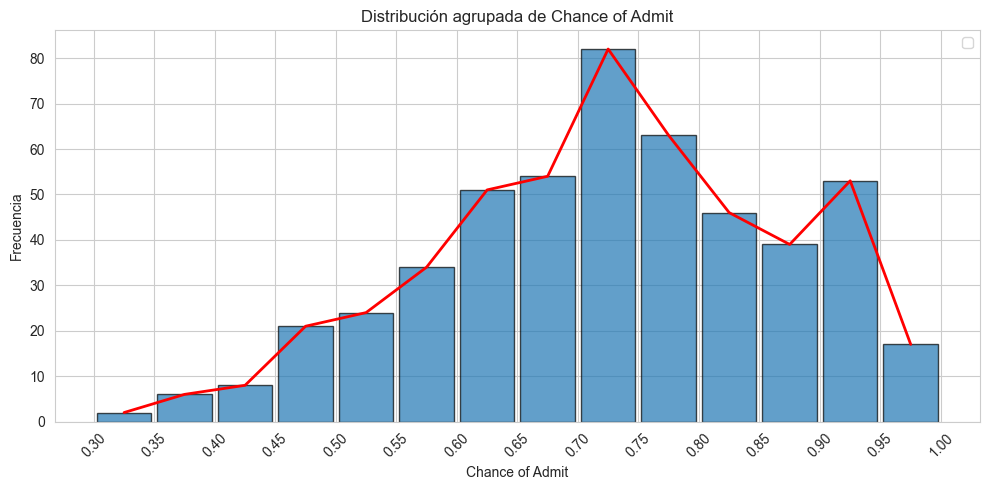

In [5]:
# Distribution of the chances of being admitted

data = df["Chance of Admit"]
bins = np.arange(0.3, 1.01, 0.05)

counts, bin_edges = np.histogram(data, bins=bins)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

plt.figure(figsize=(10, 5))
plt.bar(bin_centers, counts, width=0.045, alpha=0.7, edgecolor="black")
plt.plot(bin_centers, counts, color="red", linewidth=2,)

plt.xlabel("Chance of Admit")
plt.ylabel("Frecuencia")
plt.title("Distribución agrupada de Chance of Admit")
plt.xticks(np.arange(0.3, 1.05, 0.05), rotation=45)
plt.tight_layout()
plt.legend()
plt.show()


El dataset contiene **500 solicitudes** y, tras utilizar `Serial No.` como índice, se trabaja con **7 variables predictoras**: resultados GRE y TOEFL, valoración de la universidad, `SOP`, `LOR`, `CGPA` y experiencia de investigación.

La variable objetivo `Chance of Admit` es continua y se mueve entre **0.34** y **0.97**, con una media aproximada de **0.72** y una mediana de **0.72**. Por tanto, el problema se aborda como una tarea de **regresión** y no de clasificación: el objetivo no es asignar una clase, sino estimar una probabilidad.


## 3. Exploratory analysis

Procedemos con el estudio de como las variables afectan al objetivo `Change of admit` utilizando un heatmap

<Axes: >

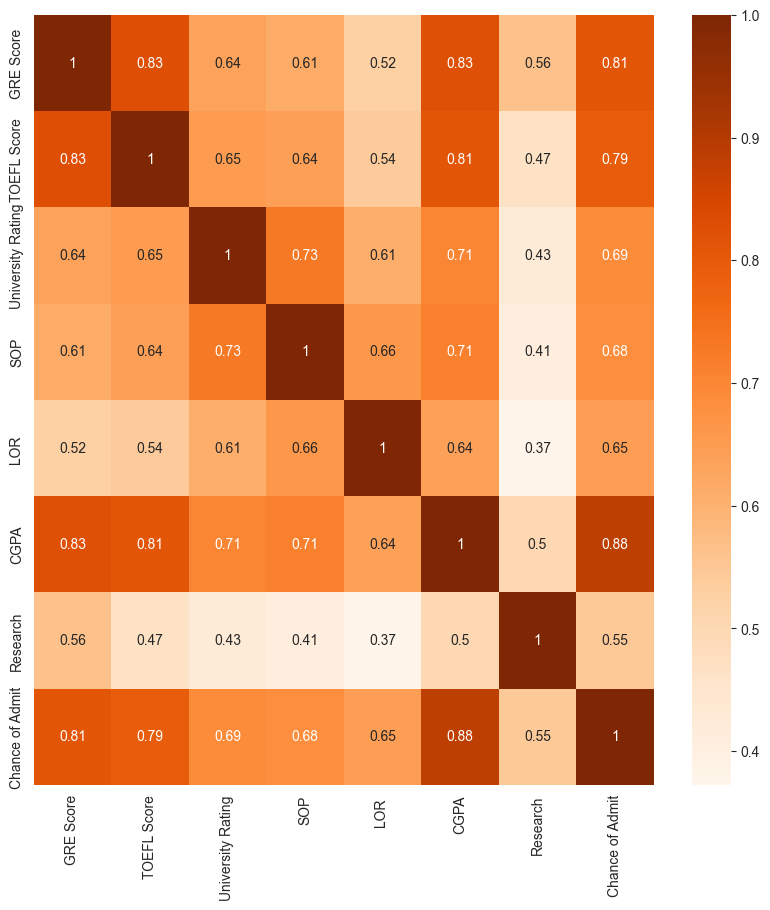

In [6]:
plt.figure(figsize=(10,10))
sns.heatmap(df.corr(), annot=True, cmap="Oranges")

AL hacer un estudio detallado de la correlación entre las *features* y la varible objetivo `Chance of Admit` observamos que las variables que más afectan a la varianza del target ordenadas de mayor a menor son: `CGPA - Cumulative Grade Point Average` que es una metrica educacional que mide el desempeño general del estudiante, `GRE Score - Graduate Record Examinations` que es el resultado del estudiante sobre el test de admisión de la universidad y `TOEFL Score - Test Of English as a Foreign Language` que mide el nivel de inglés del estudiante.

Por otra parte, si nos fijamos en la relación entre variables sin tener en cuenta el objetivo, observamos que las features  con mayor correlación entre sí son entre las variables `GRE Score`, `CGPA` y `TOEFL Score`. Por lo que podemos deducir que en el estudio no supervisado, estas variables dominarán los elementos principales de PCA.

## 4. Preprocessing: split & scale

In [7]:
y = df["Chance of Admit"]
X = df.drop(columns="Chance of Admit")

Dividimos el dataset en 70% train / 30% test antes de escalar los datos y hacemos *fit* al *scaler* solamente al conjunto del train para evitar *data leakage*

In [8]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)
print(f"Train set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")

Train set: 400 samples
Test set: 100 samples


In [9]:
sc = StandardScaler()
X_train_scaled = sc.fit_transform(X_train)
X_test_scaled = sc.transform(X_test)

## 5. Unsupervised analysis

Antes de entrenar los modelos supervisados, conviene estudiar la estructura interna del conjunto de datos sin utilizar la variable objetivo. Para ello aplicamos **PCA** sobre las variables estandarizadas y, posteriormente, **K-Means** para comprobar si aparecen perfiles de solicitantes diferenciados.

El análisis no supervisado no pretende predecir `Chance of Admit`; sirve para entender qué combinaciones de variables concentran la variabilidad del dataset y si existen grupos naturales de observaciones.


In [10]:
sc = StandardScaler()
data_scaled = sc.fit_transform(X)

pca = PCA()
scores = pca.fit_transform(data_scaled)

### 5.1 PCA biplot

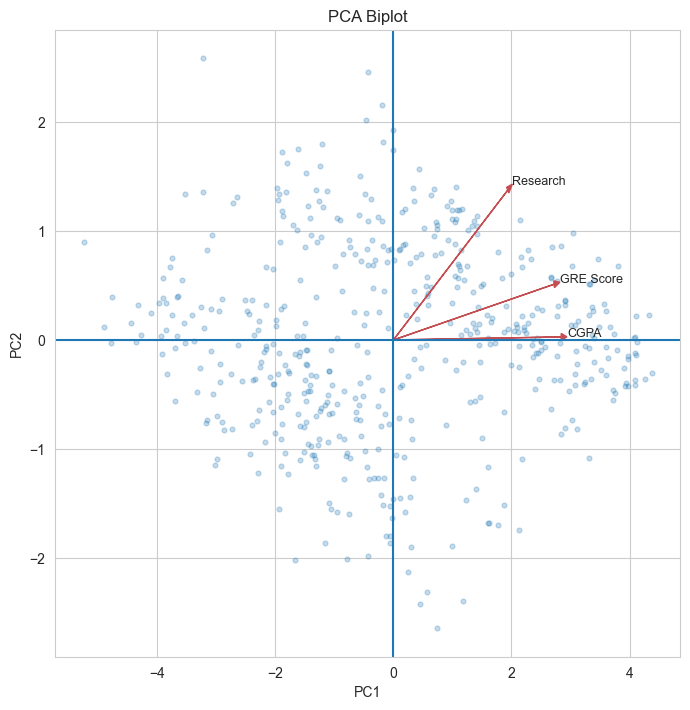

In [11]:
i, j = 0, 1

loadings = pca.components_.T * np.sqrt(pca.explained_variance_)

fig, ax = plt.subplots(figsize=(7,7))
ax.scatter(scores[:, i], scores[:, j], alpha=0.25, s=12)
ax.set_xlabel(f'PC{i+1}')
ax.set_ylabel(f'PC{j+1}')

scale_x = 0.7 * np.max(np.abs(loadings[:, i]))
scale_y = 0.7 * np.max(np.abs(loadings[:, j]))

magnitudes = np.sqrt(loadings[:, i]**2 + loadings[:, j]**2)
threshold = np.quantile(magnitudes, 0.65)

for idx in range(loadings.shape[0]):
    if magnitudes[idx] >= threshold:
        x = scale_x * loadings[idx, i] * 5
        y = scale_y * loadings[idx, j] * 5
        ax.arrow(0, 0, x, y, head_width=0.1 * max(scale_x, scale_y), length_includes_head=True, color="#C44E52")
        ax.text(x, y, X.columns[idx], fontsize=9)

ax.axhline()
ax.axvline()
plt.tight_layout()
ax.set_title('PCA Biplot')
plt.show()

### 5.2 Explained variance

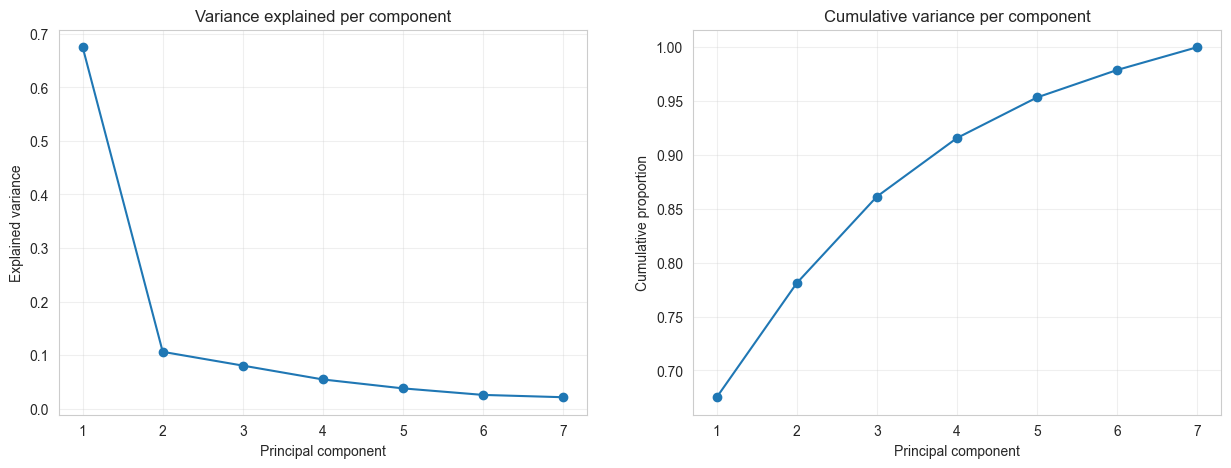

In [12]:
explained_ratio = pca.explained_variance_ratio_
cum_explained_ratio = np.cumsum(explained_ratio)

n_show = len(explained_ratio)
ticks = np.arange(1, n_show + 1)

fig, axes = plt.subplots(1,2, figsize=(15, 5))

axes[0].plot(ticks, explained_ratio, marker="o")
axes[0].set_title("Variance explained per component")
axes[0].set_ylabel("Explained variance")
axes[0].set_xlabel("Principal component")
axes[0].set_xticks(ticks)
axes[0].grid(alpha=0.3)

axes[1].plot(ticks, cum_explained_ratio, marker="o")
axes[1].set_title("Cumulative variance per component")
axes[1].set_xlabel("Principal component")
axes[1].set_ylabel("Cumulative proportion")
axes[1].set_xticks(ticks)
axes[1].grid(alpha=0.3)

### 5.3 Interpretation of PCA

El biplot y la varianza explicada deben interpretarse conjuntamente. Las variables que ya aparecían muy correlacionadas en el análisis exploratorio —especialmente `GRE Score`, `TOEFL Score` y `CGPA`— es esperable que contribuyan de manera parecida a las primeras componentes principales.

PCA reduce dimensionalidad describiendo direcciones de máxima variabilidad, pero no establece causalidad ni sustituye al análisis supervisado. En este proyecto se utiliza como herramienta de interpretación y visualización, mientras que los modelos de regresión conservan las variables originales para estimar la probabilidad de admisión.


## 6. Clustering

Aplicamos **K-Means** para buscar perfiles latentes de solicitantes a partir de sus variables académicas estandarizadas. Como el algoritmo no utiliza `Chance of Admit`, los clusters representan semejanzas entre perfiles de entrada, no categorías predefinidas de probabilidad de admisión.

Se comparan distintos valores de \(k\) con dos criterios complementarios: el **método del codo**, que mide la reducción de inercia al añadir clusters, y el **silhouette score**, que evalúa simultáneamente la cohesión interna y la separación entre grupos.


In [13]:
k_values = range(2, 8)
inertias = []
silhouettes = []

for k in k_values:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=20)
    labels = km.fit_predict(scores)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(scores, labels))

results_k = pd.DataFrame({
    "k": list(k_values),
    "inertia": inertias,
    "silhouettes": silhouettes
})
results_k

,k,inertia,silhouettes
0,2,1843.675390,0.379215
1,3,1478.063477,0.270848
2,4,1241.897524,0.275132
3,5,1105.783150,0.260269
4,6,1005.176148,0.246168
5,7,936.659995,0.239686


Suggested k by silhouettes method: 2


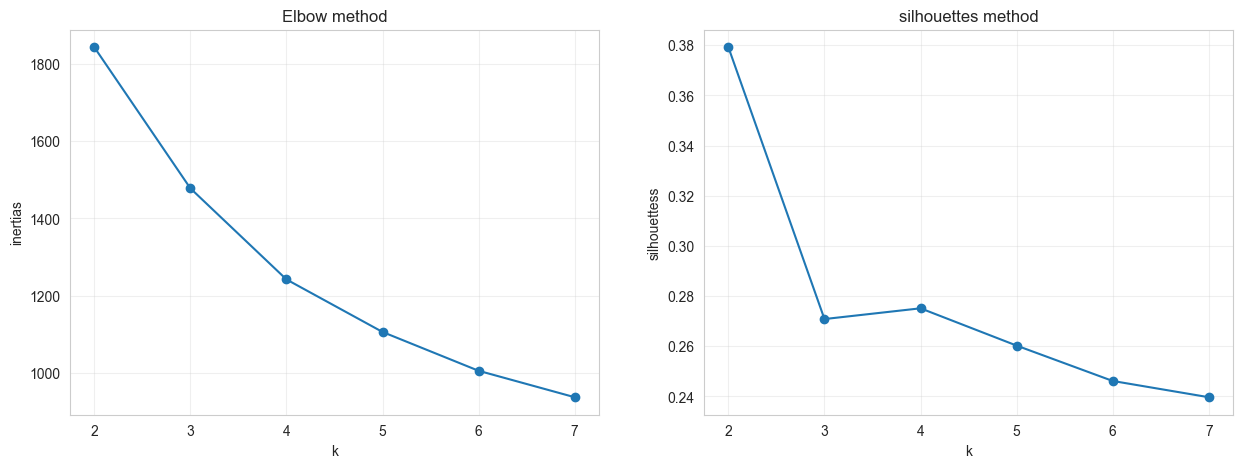

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
axes[0].plot(results_k["k"], results_k["inertia"], marker="o")
axes[0].set_title("Elbow method")
axes[0].set_xlabel("k")
axes[0].set_ylabel("inertias")
axes[0].set_xticks(k_values)
axes[0].grid(alpha=0.3)

axes[1].plot(results_k["k"], results_k["silhouettes"], marker="o")
axes[1].set_title("silhouettes method")
axes[1].set_xlabel("k")
axes[1].set_ylabel("silhouettess")
axes[1].set_xticks(k_values)
axes[1].grid(alpha=0.3)

best_k = int(results_k.loc[results_k["silhouettes"].idxmax(), "k"])
print(f"Suggested k by silhouettes method: {best_k}")

El mayor **silhouette score** se obtiene con **k = 2** (**0.379**), por lo que se seleccionan dos grupos como la partición más consistente de las analizadas. La inercia disminuye al aumentar \(k\), como ocurre por construcción en K-Means; por eso no debe utilizarse de forma aislada para justificar un número de clusters.

A continuación se examinan los tamaños y los perfiles medios de ambos grupos para comprobar qué variables explican mejor la separación.


In [15]:
k = best_k
kmeans = KMeans(n_clusters=best_k, random_state=RANDOM_STATE, n_init=20)
cluster_labels = kmeans.fit_predict(scores)

df_clusters = X.copy()
df_clusters["clusters"] = cluster_labels

print("Cluster sizes: ")
print(df_clusters["clusters"].value_counts().sort_index())

Cluster sizes: 
clusters
0    276
1    224
Name: count, dtype: int64


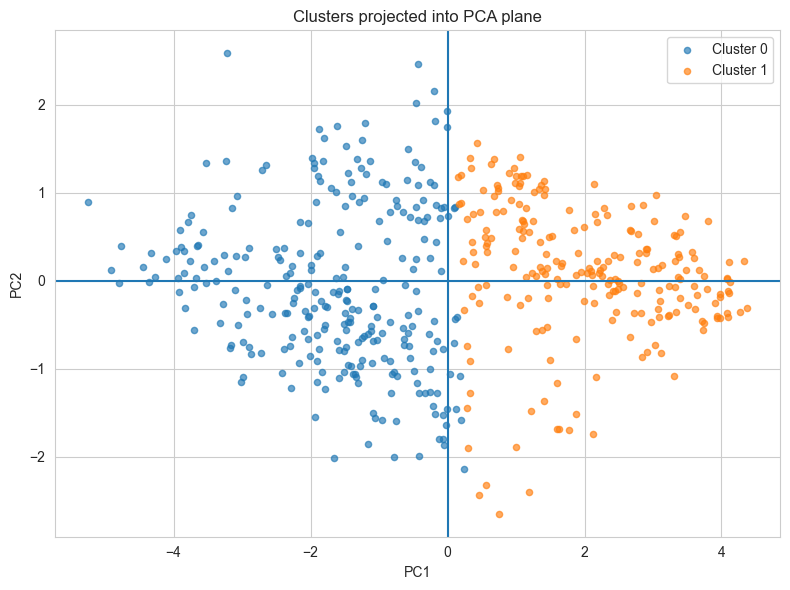

In [16]:
fig, ax = plt.subplots(figsize=(8,6))

for c in sorted(np.unique(cluster_labels)):
    mask = cluster_labels == c
    ax.scatter(scores[mask, 0], scores[mask, 1], alpha=0.65, s=20, label=f'Cluster {c}')

ax.set_title("Clusters projected into PCA plane")
ax.set_ylabel("PC2")
ax.set_xlabel("PC1")
ax.axhline(0)
ax.axvline(0)
ax.legend()
plt.tight_layout()
plt.show()

In [17]:
# Which features differetiates the clusters most?
cluster_profile = df_clusters.groupby("clusters").mean(numeric_only=True)
between_cluster_std = cluster_profile.std(axis=0).sort_values(ascending=False)

print("Features that best differentiate the clusters:")
print(between_cluster_std)

print("\nMean profile per cluster:") 
cluster_profile

Features that best differentiate the clusters:
GRE Score            11.925061
TOEFL Score           6.101815
University Rating     1.134958
SOP                   0.956305
LOR                   0.798240
CGPA                  0.647629
Research              0.432106
dtype: float64

Mean profile per cluster:


,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research
clusters,,,,,,,
0,308.916667,103.326087,2.394928,2.768116,2.978261,8.166123,0.286232
1,325.781250,111.955357,4.000000,4.120536,4.107143,9.082009,0.897321


### 6.1 Conclusions from clustering

El clustering separa el dataset en dos perfiles relativamente equilibrados: **276** solicitudes en el cluster 0 y **224** en el cluster 1. El segundo grupo presenta, de media, puntuaciones GRE y TOEFL más altas, mayor valoración universitaria, mejores `SOP` y `LOR`, un `CGPA` superior y una proporción mucho mayor de estudiantes con experiencia de investigación.

En los perfiles medios, `GRE Score` y `TOEFL Score` muestran las diferencias numéricas más grandes entre grupos. No obstante, estas magnitudes están expresadas en escalas distintas; la lectura sustantiva debe apoyarse también en que K-Means se entrenó sobre datos estandarizados. En conjunto, los clusters sugieren una estructura interpretable de perfiles académicos más competitivos frente a perfiles con credenciales medias más bajas.


## 7. Supervised Learning

En esta sección estimamos `Chance of Admit` mediante modelos de regresión. Todos se comparan sobre el mismo conjunto de test y con tres métricas complementarias:

- **R²**: proporción de variabilidad del objetivo explicada por el modelo; cuanto mayor, mejor.  
- **MAE**: error absoluto medio, expresado en las mismas unidades que la probabilidad estimada; cuanto menor, mejor.  
- **RMSE**: penaliza con mayor intensidad los errores grandes; cuanto menor, mejor.  

Los hiperparámetros de KNN, Random Forest y Gradient Boosting se seleccionan mediante `GridSearchCV` sobre los datos de entrenamiento. El conjunto de test se reserva para la evaluación final, evitando escoger modelos directamente por su rendimiento sobre observaciones no vistas.


Definimos una funcion auxiliar para evaluar cada modelo de manera homogénea

In [18]:
def evaluate_model(name, model, X_tr, y_tr, X_te, y_te):
    """
    Entrena un modelo de regresión, muestra métricas y genera
    gráficos de evaluación comparables a una matriz de confusión
    en clasificación.
    """

    model.fit(X_tr, y_tr)
    pred = model.predict(X_te)

    r2 = r2_score(y_te, pred)
    mae = mean_absolute_error(y_te, pred)
    rmse = root_mean_squared_error(y_te, pred)

    print(f"=== {name} ===")
    print(f"R²:   {r2:.4f}")
    print(f"MAE:  {mae:.4f}")
    print(f"RMSE: {rmse:.4f}")


    residuals = y_te - pred
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    # Gráfico valores reales vs predichos -----
    sns.scatterplot(
        x=y_te,
        y=pred,
        ax=axes[0],
        s=70,
        alpha=0.75
    )

    min_value = min(y_te.min(), pred.min())
    max_value = max(y_te.max(), pred.max())

    axes[0].plot(
        [min_value, max_value],
        [min_value, max_value],
        linestyle="--",
        linewidth=2,
        label="Predicción perfecta"
    )

    axes[0].set_title(f"Valores reales vs. predichos — {name}")
    axes[0].set_xlabel("Valor real")
    axes[0].set_ylabel("Valor predicho")
    axes[0].legend()

    #  Gráfico de residuos 
    sns.scatterplot(
        x=pred,
        y=residuals,
        ax=axes[1],
        s=70,
        alpha=0.75
    )

    axes[1].axhline(
        y=0,
        linestyle="--",
        linewidth=2
    )

    axes[1].set_title(f"Residuos del modelo — {name}")
    axes[1].set_xlabel("Valor predicho")
    axes[1].set_ylabel("Residuo (real − predicho)")

    plt.tight_layout()
    plt.show()

    return {
        "model": name,
        "r2": r2,
        "mae": mae,
        "rmse": rmse
    }

In [19]:
results = []

### 7.1 KNN Regression

In [20]:
param_grid_knn = {
    "n_neighbors": list(range(1, 100))
}

grid_knn = GridSearchCV(
    estimator=KNeighborsRegressor(),
    param_grid=param_grid_knn,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

grid_knn.fit(X_train_scaled, y_train)

print("Mejor número de vecinos (k):", grid_knn.best_params_["n_neighbors"])
print("Mejor RMSE medio en validación:", -grid_knn.best_score_)

Mejor número de vecinos (k): 20
Mejor RMSE medio en validación: 0.06465354059676817


Para KNN se busca el número óptimo de vecinos mediante validación cruzada. Este modelo depende de distancias entre observaciones; por ello utiliza las variables escaladas, de modo que una característica con una escala numérica mayor no domine artificialmente el cálculo de proximidad.


=== KNN Regression ===
R²:   0.7830
MAE:  0.0476
RMSE: 0.0666


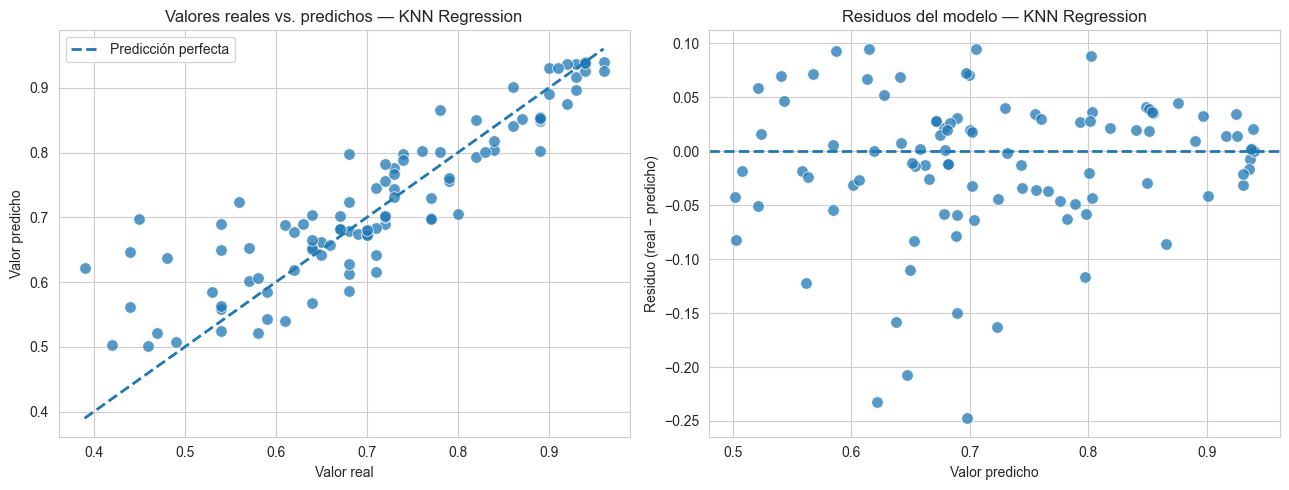

In [21]:
results.append(evaluate_model(
    "KNN Regression",
    KNeighborsRegressor(n_neighbors=20),
    X_train_scaled, y_train, X_test_scaled, y_test))

### 7.2 Linear Regression

=== Linear Regression ===
R²:   0.8188
MAE:  0.0427
RMSE: 0.0609


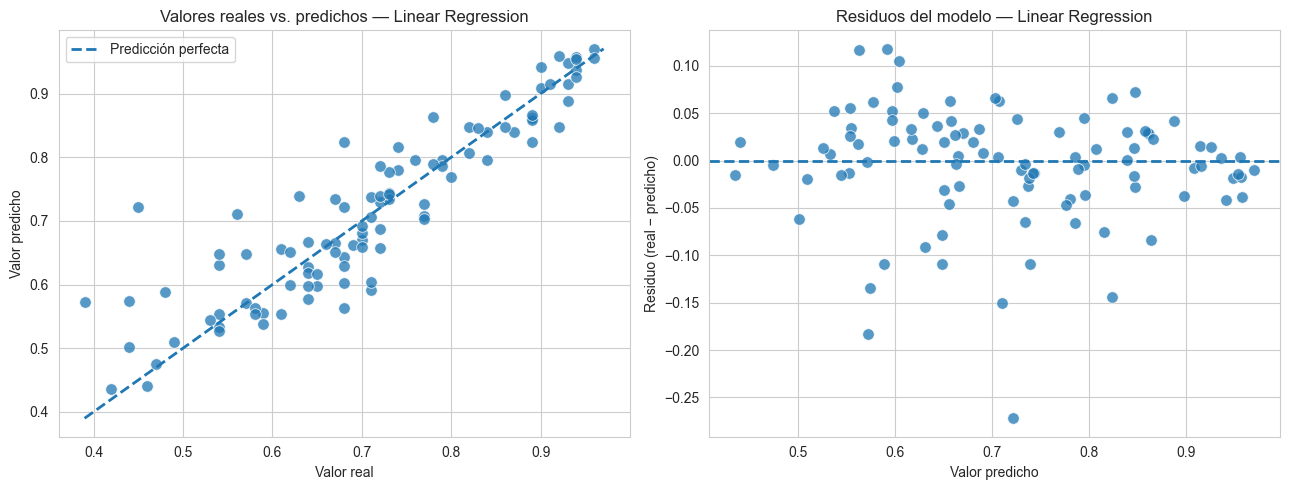

In [22]:
results.append(evaluate_model(
    "Linear Regression",
    LinearRegression(),
    X_train_scaled, y_train, X_test_scaled, y_test))

### 7.3 Random Forest Regressor

In [23]:
param_grid_rf = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 5, 10],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", 0.7]
}

grid_rf = GridSearchCV(
    estimator=RandomForestRegressor(
        random_state=RANDOM_STATE
    ),
    param_grid=param_grid_rf,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

grid_rf.fit(X_train, y_train)

print("Mejores parámetros:", grid_rf.best_params_)
print("Mejor RMSE medio en validación:", -grid_rf.best_score_)

Mejores parámetros: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 100}
Mejor RMSE medio en validación: 0.06170830506081647


=== Random Forest Regressor ===
R²:   0.8122
MAE:  0.0439
RMSE: 0.0620


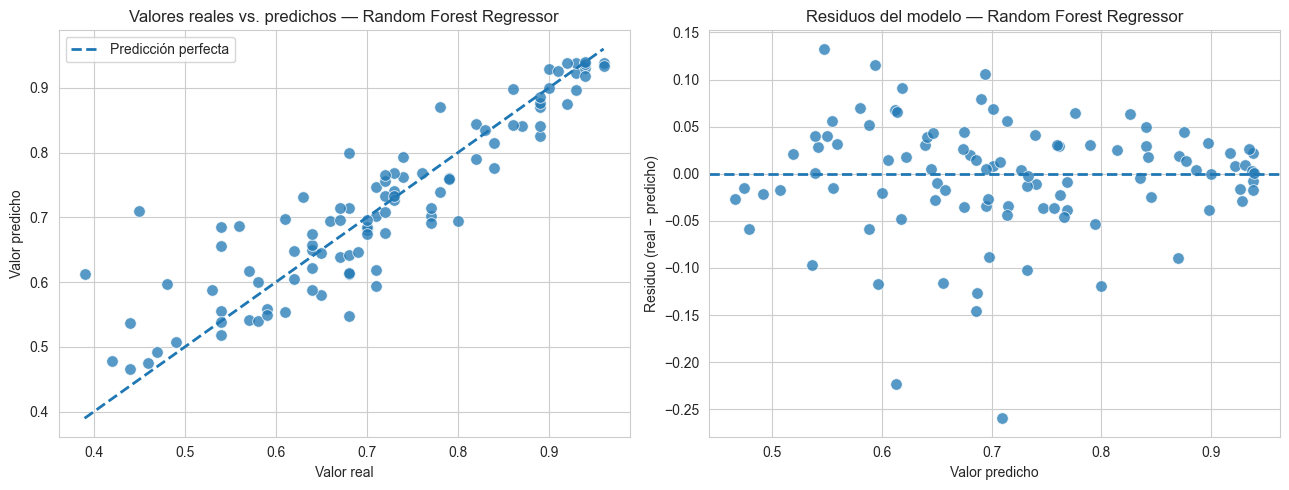

In [24]:
results.append(evaluate_model(
     "Random Forest Regressor",
    RandomForestRegressor(max_depth=None, max_features= "sqrt", min_samples_leaf= 2, min_samples_split=2, n_estimators=100),
    X_train_scaled, y_train, X_test_scaled, y_test))

### 7.4 Gradient Boosting Regressor

In [25]:
param_grid_tree = {
    "ccp_alpha": [0.0, 0.0001, 0.0005, 0.001],
    "max_depth": [3, 4, 5, 6, 7, None],
    "min_samples_leaf": [2, 4, 6, 8, 10],
    "min_samples_split": [5, 10, 15, 20, 25]
}

grid_tree = GridSearchCV(
    estimator=GradientBoostingRegressor(
        random_state=RANDOM_STATE
    ),
    param_grid=param_grid_tree,
    scoring="neg_root_mean_squared_error",
    cv=5,
    n_jobs=-1
)

# Para árboles puedes usar X_train sin escalar
grid_tree.fit(X_train, y_train)

print("Mejores parámetros:", grid_tree.best_params_)
print("Mejor RMSE medio en validación:", -grid_tree.best_score_)

Mejores parámetros: {'ccp_alpha': 0.0, 'max_depth': 3, 'min_samples_leaf': 10, 'min_samples_split': 25}
Mejor RMSE medio en validación: 0.06467034173905017


=== Gradient Boosting Regression ===
R²:   0.7947
MAE:  0.0440
RMSE: 0.0648


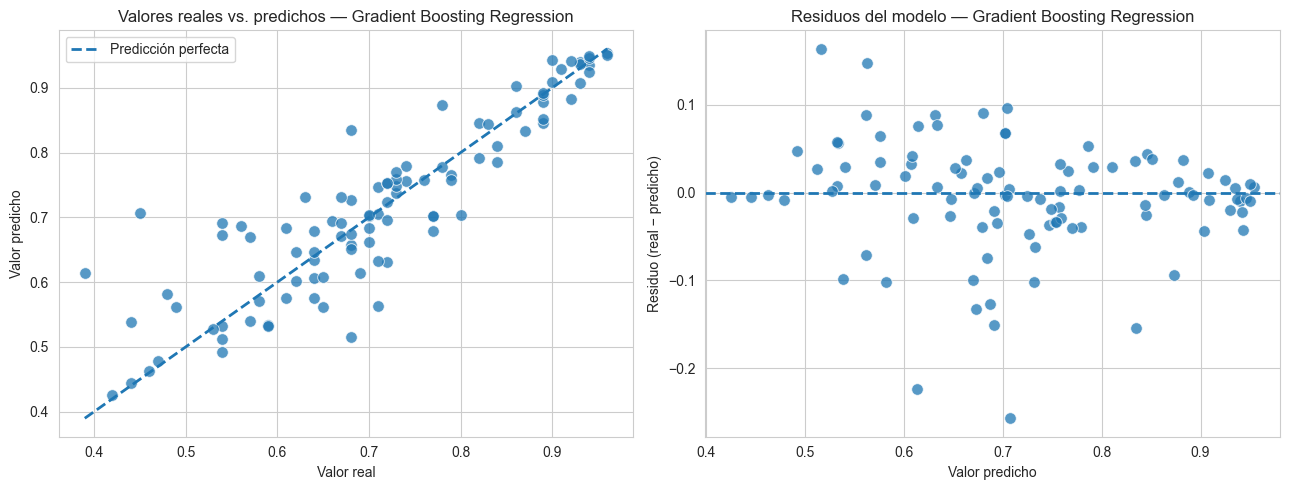

In [26]:
results.append(evaluate_model(
    "Gradient Boosting Regression",
    GradientBoostingRegressor(ccp_alpha=0.0, max_depth=3, min_samples_leaf=10, min_samples_split=25),
    X_train_scaled, y_train, X_test_scaled, y_test))

## 8. Model Comparison

In [28]:
results_df = pd.DataFrame(results).sort_values("r2", ascending=False).reset_index(drop=True)
results_df

,model,r2,mae,rmse
0,Linear Regression,0.818843,0.042723,0.060866
1,Random Forest Regressor,0.812201,0.043940,0.061972
2,Gradient Boosting Regression,0.794722,0.043957,0.064791
3,KNN Regression,0.782967,0.047615,0.066621


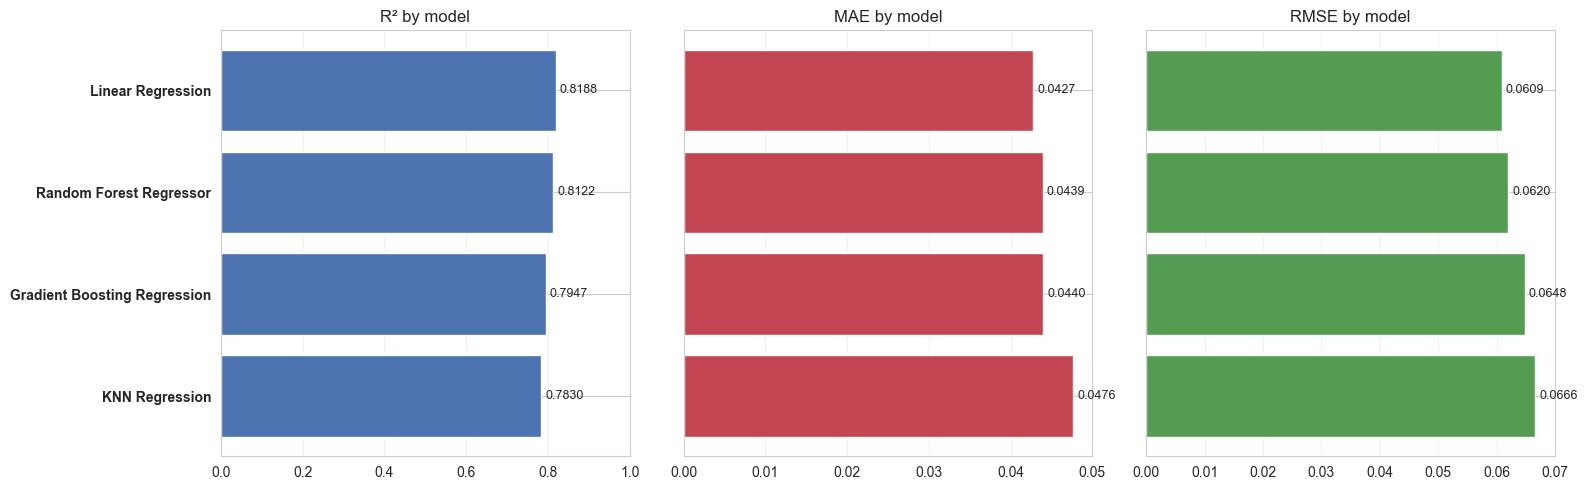

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16,5), sharey=True)

axes[0].barh(results_df["model"], results_df["r2"], color="#4C72B0")
axes[0].set_title("R² by model")
axes[0].set_xlim(0,1)
axes[0].invert_yaxis()

axes[1].barh(results_df["model"], results_df["mae"], color="#C44552")
axes[1].set_title("MAE by model")
axes[1].set_xlim(0, 0.05)

axes[2].barh(results_df["model"], results_df["rmse"], color="#539C51")
axes[2].set_title("RMSE by model")
axes[2].set_xlim(0, 0.07)

for ax in axes:
    ax.bar_label(ax.containers[0], fmt="%.4f", padding=3, fontsize=9)
    ax.grid(axis="x", alpha=0.25)
    ax.set_axisbelow(True)

axes[1].tick_params(labelleft=False)
axes[2].tick_params(labelleft=False)

for label in axes[0].get_yticklabels():
    label.set_fontweight("bold")

plt.tight_layout()
plt.show()

## 9. Conclusions

**Estructura de los datos.** El conjunto reúne 500 solicitudes y siete variables académicas y de perfil. La probabilidad de admisión presenta un rango amplio, entre 0.34 y 0.97, lo que permite plantear un problema de regresión con variación suficiente en la variable objetivo. En el análisis exploratorio, `CGPA`, `GRE Score` y `TOEFL Score` destacan como las variables con mayor relación con `Chance of Admit`.

**Análisis no supervisado (PCA + K-Means).** La correlación observada entre los principales indicadores académicos es coherente con el análisis por componentes principales: estas variables contribuyen de forma relevante a la estructura latente del dataset. K-Means, seleccionado con **k = 2** por obtener el mejor silhouette score (**0.379**), separa perfiles de solicitantes con credenciales medias más bajas y perfiles con puntuaciones, valoraciones y experiencia investigadora más altas.

**Aprendizaje supervisado.** Se compararon cuatro modelos de regresión sobre el mismo conjunto de test:

| Modelo | R² | MAE | RMSE |
|---|---:|---:|---:|
| **Linear Regression** | **0.8188** | **0.0427** | **0.0609** |
| Random Forest Regressor | 0.8122 | 0.0439 | 0.0620 |
| Gradient Boosting Regression | 0.7947 | 0.0440 | 0.0648 |
| KNN Regression | 0.7830 | 0.0476 | 0.0666 |

La **Regresión Lineal** obtiene el mejor resultado en las tres métricas. Con un R² de aproximadamente **0.819**, explica cerca del 82% de la variabilidad observada en la probabilidad de admisión; además, su error absoluto medio es de solo **0.043**.

**Conclusión final.** Los resultados sugieren que, para este conjunto y esta partición de datos, la relación entre las credenciales académicas y la probabilidad de admisión se aproxima razonablemente bien mediante una combinación lineal de las variables disponibles. Random Forest y Gradient Boosting ofrecen un rendimiento muy competitivo, pero su mayor complejidad no produce una mejora respecto al modelo lineal. Por tanto, la Regresión Lineal resulta preferible aquí por combinar el mejor rendimiento con una interpretación más directa.
